# CCA demo

In [23]:
import os
from importlib import reload
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy as ctp
import seaborn as sns
from sklearn import mixture, decomposition
import cartopy.crs as ccrs
import cartopy.feature as feature
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.util import add_cyclic_point
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.ticker as mticker
from datetime import datetime, timedelta
import xesmf as xe

In [2]:
# data

# SST
SST = xr.open_dataset("/groups/XDU5/Go/observations/ERSST/sst.mnmean.v4.nc")

# Precipitation
PRECIP = xr.open_dataset("/groups/XDU5/Go/observations/GPCCv6/full_data_v6_precip_05.nc")

# Nino3.4 index
NINO34 = xr.open_dataset("/groups/XDU5/Go/observations/ERSST/nina34.anom.nc")

In [3]:
# Extracting subsets

sst = SST.sst
precip = PRECIP.p
nino34 = NINO34.value

In [4]:
def detrend_da(da, dim='time'):
    """
    Remove linear trend along dim from an xarray DataArray or Dataset variable.
    Handles NaNs by fitting only on finite values.
    """
    x = np.arange(da.sizes[dim])

    def _polyfit_nan(y):
        mask = np.isfinite(y)
        if mask.sum() < 2:
            return np.array([np.nan, np.nan], dtype=float)
        return np.polyfit(x[mask], y[mask], 1)

    coeffs = xr.apply_ufunc(
        _polyfit_nan,
        da,
        input_core_dims=[[dim]],
        output_core_dims=[["coef"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    slope = coeffs.sel(coef=0)
    intercept = coeffs.sel(coef=1)
    x_da = xr.DataArray(x, dims=[dim], coords={dim: da[dim]})
    trend = slope * x_da + intercept
    return da - trend

# Examples: detrend existing variables
sst_detrended = detrend_da(sst, dim='time')
precip_detrended = detrend_da(precip, dim='time')
nino34_detrended = detrend_da(nino34, dim='time')

In [5]:
# Subset SST for extended winter (Nov-Apr) in the region 100°E-100°W, 26°S-66°N
sst_subset = sst_detrended.sel(
    lon=slice(100, 260),  # 100°E to 100°W (100 to 260 in 0-360 convention)
    lat=slice(66, -26)
)
sst_subset = sst_subset.isel(time=sst_subset.time.dt.month.isin([11, 12, 1, 2, 3, 4]))

# Subset precipitation for extended winter (Nov-Apr) in the region 122°W-114°W, 32°N-36°N
precip_subset = precip_detrended.sel(
    lon=slice(-122, -114),
    lat=slice(32, 36)
)
precip_subset = precip_subset.isel(time=precip_subset.time.dt.month.isin([11, 12, 1, 2, 3, 4]))

# Extract time period 1900-10 to 2013-04 for both variables
sst_subset = sst_subset.sel(time=slice('1900-10', '2013-04'))
precip_subset = precip_subset.sel(time=slice('1900-10', '2013-04'))

In [6]:
# Group by year and calculate extended winter averages
# Extended winter: Nov of previous year + Dec, Jan, Feb, Mar, Apr of current year

# For SST subset
sst_season_year = sst_subset.time.dt.year.copy()
# Shift November dates to the following year for grouping
sst_season_year = sst_season_year.where(sst_subset.time.dt.month != 11, sst_subset.time.dt.year + 1)

sst_seasonal_mean = sst_subset.groupby(sst_season_year).mean(dim='time')
sst_seasonal_mean = sst_seasonal_mean.rename({'year': 'season_year'})

# For precipitation subset
precip_season_year = precip_subset.time.dt.year.copy()
# Shift November dates to the following year for grouping
precip_season_year = precip_season_year.where(precip_subset.time.dt.month != 11, precip_subset.time.dt.year + 1)

precip_seasonal_mean = precip_subset.groupby(precip_season_year).mean(dim='time')
precip_seasonal_mean = precip_seasonal_mean.rename({'year': 'season_year'})

print("SST seasonal mean shape:", sst_seasonal_mean.shape)
print("Precipitation seasonal mean shape:", precip_seasonal_mean.shape)

SST seasonal mean shape: (114, 47, 81)
Precipitation seasonal mean shape: (111, 8, 16)


In [7]:
# Calculate 3-month running mean of Niño3.4
nino34_3m = nino34_detrended.rolling(time=3, center=True).mean()

## PCA to reduce the dimentionality

In [8]:
# Reshape SST and precipitation data for PCA
# Flatten spatial dimensions while keeping time dimension

# SST: reshape to (time, space)
sst_data = sst_seasonal_mean.values.reshape(sst_seasonal_mean.sizes['season_year'], -1)

# Precipitation: reshape to (time, space)
precip_data = precip_seasonal_mean.values.reshape(precip_seasonal_mean.sizes['season_year'], -1)

# Remove NaN values for PCA
sst_valid = sst_data[:, ~np.isnan(sst_data[1])]
precip_valid = precip_data[:, ~np.isnan(precip_data[1])]

# Apply PCA to extract first 10 leading components
n_components_sst = 10
n_components_precip = 5

pca_sst = decomposition.PCA(n_components=n_components_sst)
pca_precip = decomposition.PCA(n_components=n_components_precip)

# Fit PCA and transform data
sst_pca = pca_sst.fit_transform(sst_valid)
precip_pca = pca_precip.fit_transform(precip_valid)

# Print explained variance ratio
print(f"SST - Explained variance ratio: {pca_sst.explained_variance_ratio_}")
print(f"SST - Cumulative explained variance: {np.cumsum(pca_sst.explained_variance_ratio_)}")
print(f"\nPrecipitation - Explained variance ratio: {pca_precip.explained_variance_ratio_}")
print(f"Precipitation - Cumulative explained variance: {np.cumsum(pca_precip.explained_variance_ratio_)}")

# Convert to DataArrays for easier manipulation
sst_pca_da = xr.DataArray(
    sst_pca,
    dims=['time', 'component'],
    coords={'component': np.arange(1, n_components_sst + 1)}
)

precip_pca_da = xr.DataArray(
    precip_pca,
    dims=['time', 'component'],
    coords={'component': np.arange(1, n_components_precip + 1)}
)

SST - Explained variance ratio: [0.32413892 0.10308694 0.08934606 0.07556944 0.05921972 0.04414092
 0.03139023 0.02862621 0.02670508 0.01962302]
SST - Cumulative explained variance: [0.32413892 0.42722585 0.51657192 0.59214135 0.65136108 0.695502
 0.72689223 0.75551845 0.78222352 0.80184654]

Precipitation - Explained variance ratio: [0.80435481 0.07522942 0.0249153  0.01914479 0.01401557]
Precipitation - Cumulative explained variance: [0.80435481 0.87958423 0.90449953 0.92364432 0.93765989]


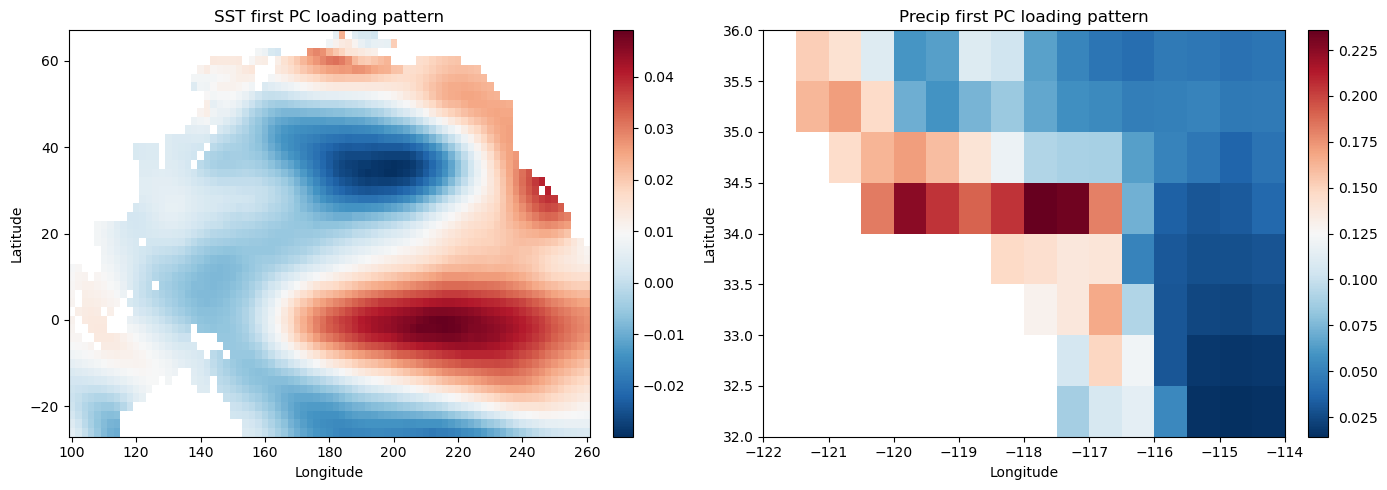

In [9]:
# Spatial pattern of the first principal component (loading pattern) for SST and precipitation

# Reconstruct the first PC loading pattern on the original SST grid
sst_valid_mask = ~np.isnan(sst_data[1])
sst_pc1_loading = pca_sst.components_[0]

sst_pc1_pattern_flat = np.full(sst_data.shape[1], np.nan, dtype=float)
sst_pc1_pattern_flat[sst_valid_mask] = sst_pc1_loading
sst_pc1_pattern = sst_pc1_pattern_flat.reshape(sst_subset.sizes["lat"], sst_subset.sizes["lon"])

# Reconstruct the first PC loading pattern on the original precipitation grid
precip_valid_mask = ~np.isnan(precip_data[1])
precip_pc1_loading = pca_precip.components_[0]

precip_pc1_pattern_flat = np.full(precip_data.shape[1], np.nan, dtype=float)
precip_pc1_pattern_flat[precip_valid_mask] = precip_pc1_loading
precip_pc1_pattern = precip_pc1_pattern_flat.reshape(precip_subset.sizes["lat"], precip_subset.sizes["lon"])

# Convert to xarray objects for easy inspection
sst_pc1_pattern_da = xr.DataArray(
    sst_pc1_pattern,
    dims=("lat", "lon"),
    coords={"lat": sst_subset.lat.values, "lon": sst_subset.lon.values},
    name="SST_PC1_loading_pattern",
)

precip_pc1_pattern_da = xr.DataArray(
    precip_pc1_pattern,
    dims=("lat", "lon"),
    coords={"lat": precip_subset.lat.values, "lon": precip_subset.lon.values},
    name="PRECIP_PC1_loading_pattern",
)

# Display the patterns
sst_pc1_pattern_da
precip_pc1_pattern_da

# Optional quick visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].pcolormesh(
    sst_subset.lon.values,
    sst_subset.lat.values,
    sst_pc1_pattern,
    cmap="RdBu_r",
    shading="auto",
)
axes[0].set_title("SST first PC loading pattern")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].pcolormesh(
    precip_subset.lon.values,
    precip_subset.lat.values,
    precip_pc1_pattern,
    cmap="RdBu_r",
    shading="auto",
)
axes[1].set_title("Precip first PC loading pattern")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# Build PCA-score DataArrays with real time coordinates
sst_pca_scores = xr.DataArray(
    sst_pca,
    dims=("season_year", "sst_component"),
    coords={
        "season_year": sst_seasonal_mean.season_year.values,
        "sst_component": np.arange(1, n_components_sst + 1),
    },
)

precip_pca_scores = xr.DataArray(
    precip_pca,
    dims=("season_year", "precip_component"),
    coords={
        "season_year": precip_seasonal_mean.season_year.values,
        "precip_component": np.arange(1, n_components_precip + 1),
    },
)

# 1990-2012
#sst_pca_scores = sst_pca_scores.sel(season_year=slice(1990, 2013))
#precip_pca_scores = precip_pca_scores.sel(season_year=slice(1990, 2013))

# Keep only the overlapping months between the two PCA score series
sst_aligned, precip_aligned = xr.align(
    sst_pca_scores, precip_pca_scores, join="inner"
)

print(sst_aligned.data.shape)
print(precip_aligned.data.shape)

In [13]:
from sklearn.cross_decomposition import CCA

cca = CCA(n_components=3)
cca.fit(sst_aligned.data, precip_aligned.data)

# Transform the data to get the canonical variates
sst_c, precip_c = cca.transform(sst_aligned.data, precip_aligned.data)

In [17]:
for i in range(3):
    print(f"Correlation between SST canonical variate {i+1} and Precip canonical variate {i+1}:")
    print(np.corrcoef(sst_c[:, i], precip_c[:, i])[0, 1])

correlations = [np.corrcoef(sst_c[:, i], precip_c[:, i])[0, 1] for i in range(3)]

Correlation between SST canonical variate 1 and Precip canonical variate 1:
0.6402154675306096
Correlation between SST canonical variate 2 and Precip canonical variate 2:
0.44288837421585997
Correlation between SST canonical variate 3 and Precip canonical variate 3:
0.35432326018958776


Creating Figure 1...
Figure saved as 'figure1_cca_reproduction.png'


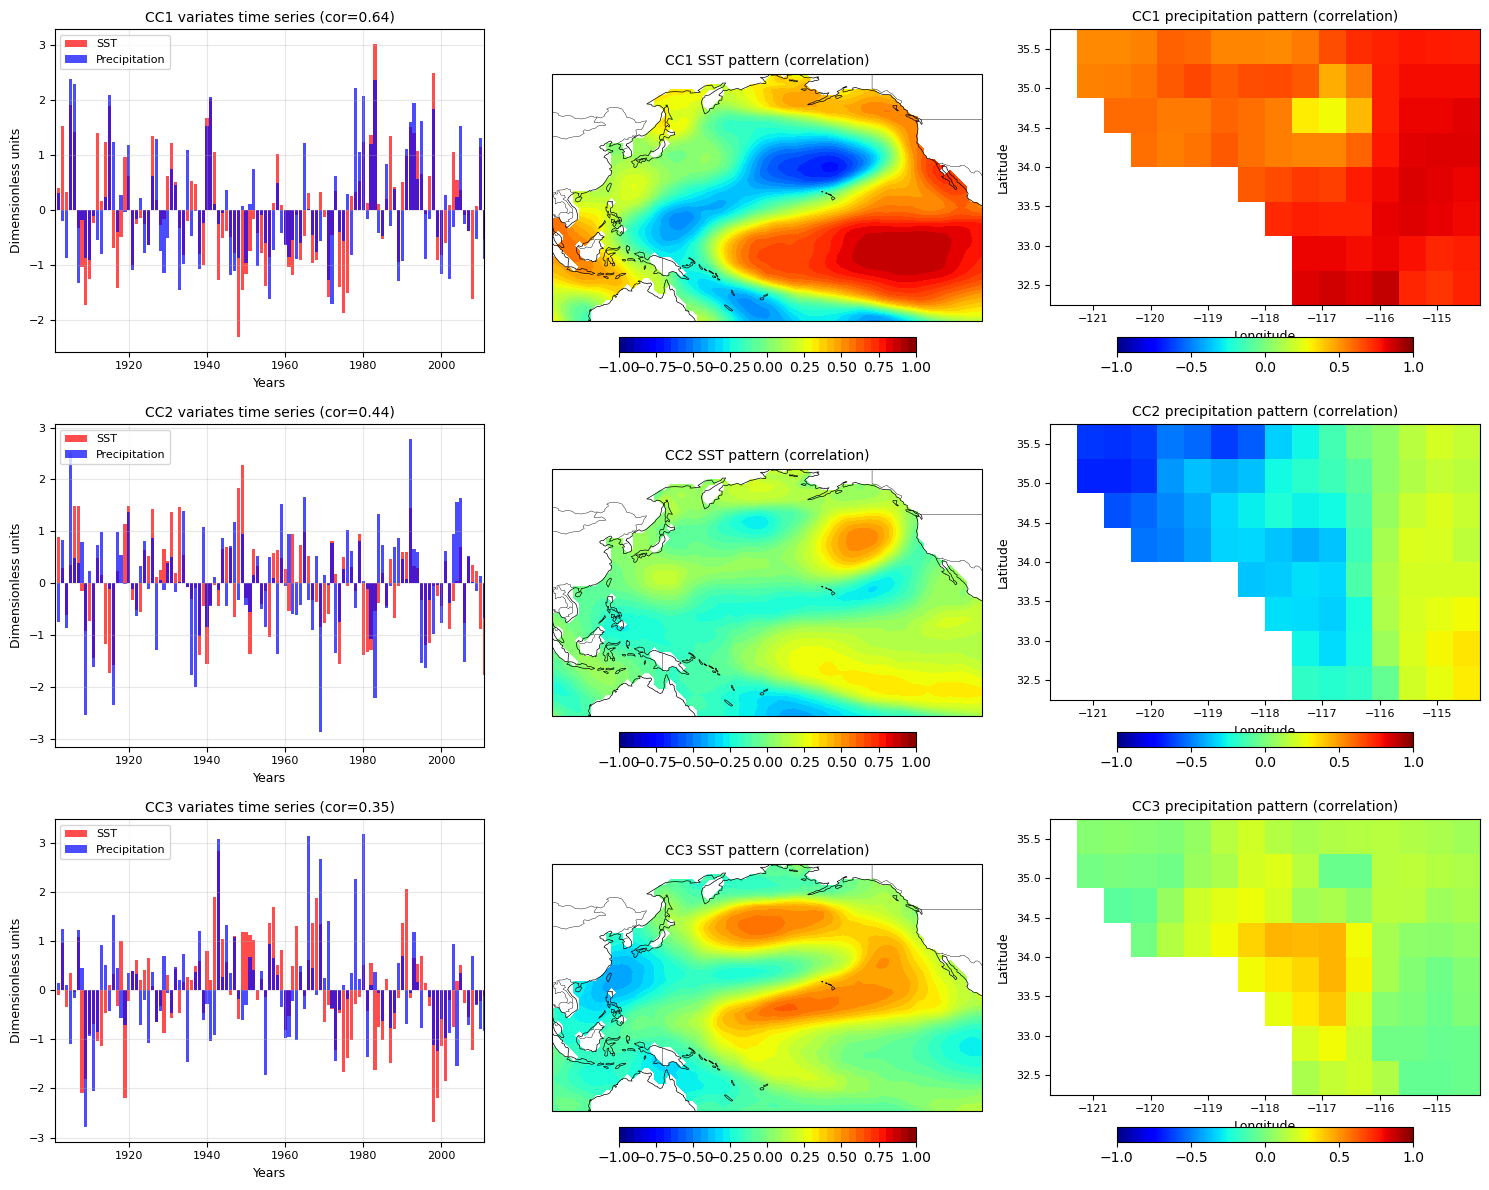

In [53]:
def plot_figure1(sst_c, precip_c, correlations, sst_original, precip_original,
                 years, lon_sst, lat_sst, lon_precip, lat_precip, nino34):
    """
    Reproduce Figure 1: Three leading CCA modes
    """
    fig = plt.figure(figsize=(15, 12))

    cmap_cca = "jet"
    
    # Create subplots for each CCA mode
    for mode in range(3):
        # Time series (left column)
        ax_ts = plt.subplot(3, 3, mode*3 + 1)
        
        # Plot bars
        x = years
        width = 0.8
        ax_ts.bar(x, sst_c[:, mode], width=width, color='red', alpha=0.7, label='SST')
        ax_ts.bar(x, precip_c[:, mode], width=width, color='blue', alpha=0.7, label='Precipitation')
        
        # Add Nino 3.4 line for first mode
        #if mode == 0:
        #    ax2 = ax_ts.twinx()
        #    ax2.plot(years, nino34, 'k-', linewidth=1.5, label='Nino 3.4')
        #    ax2.set_ylabel('Nino 3.4 SST anomaly', fontsize=9)
        #    ax2.tick_params(labelsize=8)
            
            # Calculate correlation with Nino 3.4
        #    corr_nino = np.corrcoef(sst_c[:, mode], nino34)[0, 1]
        #    ax_ts.text(0.02, 0.98, f'r(Nino3.4)={corr_nino:.2f}', 
        #              transform=ax_ts.transAxes, va='top', fontsize=8)
        
        ax_ts.set_xlabel('Years', fontsize=9)
        ax_ts.set_ylabel('Dimensionless units', fontsize=9)
        ax_ts.set_title(f'CC{mode+1} variates time series (cor={correlations[mode]:.2f})', 
                       fontsize=10)
        ax_ts.legend(loc='upper left', fontsize=8)
        ax_ts.grid(alpha=0.3)
        ax_ts.tick_params(labelsize=8)
        ax_ts.set_xlim([years[0], years[-1]])
        
        # SST pattern (middle column)
        ax_sst = plt.subplot(3, 3, mode*3 + 2, projection=ccrs.PlateCarree(central_longitude=180))
        
        # Convert longitude to -180 to 180 for plotting
        lon_sst_plot = lon_sst #np.where(lon_sst > 180, lon_sst - 360, lon_sst)
        
        # Plot
        levels = np.arange(-1, 1.01, 0.05)

        # Correlation between the leading canonical variate and SST at each grid point
        sst_cca = sst_c[:, mode]
        sst_original = sst_original

        # Flatten SST to (time, grid_point)
        sst_flat = sst_original.values.reshape(sst_original.sizes['season_year'], -1)

        # Compute correlation at each grid point, ignoring NaNs
        corrs = np.full(sst_flat.shape[1], np.nan, dtype=float)
        for i in range(sst_flat.shape[1]):
            mask = np.isfinite(sst_cca) & np.isfinite(sst_flat[:, i])
            if mask.sum() >= 2:
                corrs[i] = np.corrcoef(sst_cca[mask], sst_flat[mask, i])[0, 1]

        # Reshape back to SST grid and wrap as xarray DataArray
        sst_corr_pattern = xr.DataArray(
            corrs.reshape(sst_original.sizes['lat'], sst_original.sizes['lon']),
            dims=('lat', 'lon'),
            coords={'lat': sst_original.lat.values, 'lon': sst_original.lon.values},
            name='SST_CCA_correlation_pattern'
        )
        cs = ax_sst.contourf(lon_sst_plot, lat_sst, sst_corr_pattern, 
                            levels=levels, cmap=cmap_cca, #extend='both',
                            transform=ccrs.PlateCarree())
        ax_sst.coastlines(linewidth=0.5)
        ax_sst.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax_sst.set_xlabel('Longitude', fontsize=9)
        ax_sst.set_ylabel('Latitude', fontsize=9)
        ax_sst.set_title(f'CC{mode+1} SST pattern (correlation)', fontsize=10)
        plt.colorbar(cs, ax=ax_sst, orientation='horizontal', pad=0.05, 
                    fraction=0.046)#, label='Correlation')
        
        # Precipitation pattern (right column)
        ax_precip = plt.subplot(3, 3, mode*3 + 3)
        
        # Correlation between the leading canonical variate and SST at each grid point
        precip_cca = precip_c[:, mode]
        precip_original = precip_original

        # Flatten SST to (time, grid_point)
        precip_flat = precip_original.values.reshape(precip_original.sizes['season_year'], -1)

        # Compute correlation at each grid point, ignoring NaNs
        corrs = np.full(precip_flat.shape[1], np.nan, dtype=float)
        for i in range(precip_flat.shape[1]):
            mask = np.isfinite(precip_cca) & np.isfinite(precip_flat[:, i])
            if mask.sum() >= 2:
                corrs[i] = np.corrcoef(precip_cca[mask], precip_flat[mask, i])[0, 1]

        # Reshape back to SST grid and wrap as xarray DataArray
        precip_corr_pattern = xr.DataArray(
            corrs.reshape(precip_original.sizes['lat'], precip_original.sizes['lon']),
            dims=('lat', 'lon'),
            coords={'lat': precip_original.lat.values, 'lon': precip_original.lon.values},
            name='PRECIP_CCA_correlation_pattern'
        )
        
        # Plot
        im = ax_precip.imshow(precip_corr_pattern, aspect='auto', origin='lower',
                             extent=[lon_precip.min(), lon_precip.max(),
                                   lat_precip.min(), lat_precip.max()],
                             cmap=cmap_cca, vmin=-1, vmax=1)
        ax_precip.set_xlabel('Longitude', fontsize=9)
        ax_precip.set_ylabel('Latitude', fontsize=9)
        ax_precip.set_title(f'CC{mode+1} precipitation pattern (correlation)', fontsize=10)
        ax_precip.tick_params(labelsize=8)
        plt.colorbar(im, ax=ax_precip, orientation='horizontal', pad=0.1,
                    fraction=0.046)#, label='Correlation')
    
    plt.tight_layout()
    plt.savefig('figure1_cca_reproduction.png', dpi=300, bbox_inches='tight')
    print("Figure saved as 'figure1_cca_reproduction.png'")
    plt.show()

years = sst_aligned.season_year
lon_sst = sst_subset.lon.values
lat_sst = sst_subset.lat.values
lon_precip = precip_subset.lon.values
lat_precip = precip_subset.lat.values
nino34_aligned = nino34_3m.groupby("time.year").mean(dim='time').sel(year=slice('1990', '2011'))

# Plot Figure 1
print("Creating Figure 1...")
plot_figure1(sst_c, precip_c, correlations, sst_seasonal_mean.sel(season_year=slice('1901', '2011')), precip_seasonal_mean,
                years, lon_sst, lat_sst, lon_precip, lat_precip, nino34_aligned)

In [29]:
print("\nAnalysis complete!")


Analysis complete!
